In [1]:
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(
    credential=DefaultAzureCredential()
)

data_asset = ml_client.data.get(
    name="train",
    version="1"   # change only if your version differs
)

print("Base path:", data_asset.path)

csv_path = data_asset.path + "train.csv"
df = pd.read_csv(csv_path)

print("Train shape:", df.shape)
df.head()

Found the config file in: /config.json
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (3.1.1) and mlflow-skinny (2.22.1) are different. This may lead to unexpected behavior. Please install the same version of both packages.
  mlflow.mismatch._check_version_mismatch()


Base path: azureml://subscriptions/05089bc0-764a-404d-893e-2fc1f23863ab/resourcegroups/polymers/workspaces/poymerblends/datastores/workspaceblobstore/paths/UI/2026-01-07_043816_UTC/train/
Train shape: (7973, 7)


,id,SMILES,Tg,FFV,Tc,Density,Rg
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,NaN,0.374645,0.205667,NaN,NaN
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,NaN,0.370410,NaN,NaN,NaN
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,NaN,0.378860,NaN,NaN,NaN
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,NaN,0.387324,NaN,NaN,NaN
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,NaN,0.355470,NaN,NaN,NaN


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    return np.array(fp)

# Generate fingerprints
df["FP"] = df["SMILES"].apply(smiles_to_fp)

# Remove invalid rows
df = df[df["FP"].notnull()]

In [4]:
X = np.stack(df["FP"].values)

y_tc  = df["Tc"].values
y_tg  = df["Tg"].values
y_den = df["Density"].values
y_ffv = df["FFV"].values
y_rg  = df["Rg"].values

In [5]:
from sklearn.model_selection import train_test_split

X_train_tc, X_test_tc, y_train_tc, y_test_tc = train_test_split(X, y_tc, test_size=0.2, random_state=42)
X_train_tg, X_test_tg, y_train_tg, y_test_tg = train_test_split(X, y_tg, test_size=0.2, random_state=42)
X_train_den, X_test_den, y_train_den, y_test_den = train_test_split(X, y_den, test_size=0.2, random_state=42)
X_train_ffv, X_test_ffv, y_train_ffv, y_test_ffv = train_test_split(X, y_ffv, test_size=0.2, random_state=42)
X_train_rg, X_test_rg, y_train_rg, y_test_rg = train_test_split(X, y_rg, test_size=0.2, random_state=42)

In [6]:
import joblib

rf_tc = joblib.load("rf_tc.pkl")
rf_tg = joblib.load("rf_tg.pkl")
rf_den = joblib.load("rf_density.pkl")
rf_ffv = joblib.load("rf_ffv.pkl")
rf_rg = joblib.load("rf_rg.pkl")

print("Models loaded!")

Models loaded!


In [7]:
print("X_test_tg:", X_test_tg.shape)
print("y_test_tg:", y_test_tg.shape)
print("y_pred_tg:", y_pred_tg.shape)

X_test_tg: (1595, 2048)
y_test_tg: (1595,)


NameError: name 'y_pred_tg' is not defined

In [8]:
import numpy as np

print("NaN in X_test_tg:", np.isnan(X_test_tg).sum())
print("NaN in y_test_tg:", np.isnan(y_test_tg).sum())

NaN in X_test_tg: 0
NaN in y_test_tg: 1508


In [9]:
# Remove rows where Tg is NaN
df_clean = df.dropna(subset=["Tg"]).copy()

print("Original:", df.shape)
print("Clean:", df_clean.shape)

Original: (7973, 8)
Clean: (511, 8)


In [10]:
# Convert fingerprints
X_all = np.stack(df_clean["FP"].values)
y_all = df_clean["Tg"].values

from sklearn.model_selection import train_test_split

X_train_tg, X_test_tg, y_train_tg, y_test_tg = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

In [11]:
print("NaN in y_test_tg:", np.isnan(y_test_tg).sum())

NaN in y_test_tg: 0


In [12]:
y_pred_tg = rf_tg.predict(X_test_tg)

In [13]:
df_tg  = df.dropna(subset=["Tg"])
df_tc  = df.dropna(subset=["Tc"])
df_den = df.dropna(subset=["Density"])
df_ffv = df.dropna(subset=["FFV"])
df_rg  = df.dropna(subset=["Rg"])

In [14]:
def prepare_data(df, target):
    df_clean = df.dropna(subset=[target]).copy()
    X = np.stack(df_clean["FP"].values)
    y = df_clean[target].values
    return train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train_tg, X_test_tg, y_train_tg, y_test_tg = prepare_data(df, "Tg")
X_train_tc, X_test_tc, y_train_tc, y_test_tc = prepare_data(df, "Tc")

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_tg = rf_tg.predict(X_test_tg)

print("MAE Tg:", mean_absolute_error(y_test_tg, y_pred_tg))
print("R2 Tg:", r2_score(y_test_tg, y_pred_tg))

MAE Tg: 57.408811225777185
R2 Tg: 0.4407349866147422


In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import joblib

# Load trained models
rf_tg  = joblib.load("rf_tg.pkl")
rf_tc  = joblib.load("rf_tc.pkl")
rf_den = joblib.load("rf_density.pkl")
rf_ffv = joblib.load("rf_ffv.pkl")
rf_rg  = joblib.load("rf_rg.pkl")

# Function to prepare clean data
def prepare_data(df, target):
    df_clean = df.dropna(subset=[target]).copy()
    X = np.stack(df_clean["FP"].values)
    y = df_clean[target].values
    
    return train_test_split(X, y, test_size=0.2, random_state=42)

# Prepare datasets
X_train_tg, X_test_tg, y_train_tg, y_test_tg = prepare_data(df, "Tg")
X_train_tc, X_test_tc, y_train_tc, y_test_tc = prepare_data(df, "Tc")
X_train_den, X_test_den, y_train_den, y_test_den = prepare_data(df, "Density")
X_train_ffv, X_test_ffv, y_train_ffv, y_test_ffv = prepare_data(df, "FFV")
X_train_rg, X_test_rg, y_train_rg, y_test_rg = prepare_data(df, "Rg")

# Predict
y_pred_tg  = rf_tg.predict(X_test_tg)
y_pred_tc  = rf_tc.predict(X_test_tc)
y_pred_den = rf_den.predict(X_test_den)
y_pred_ffv = rf_ffv.predict(X_test_ffv)
y_pred_rg  = rf_rg.predict(X_test_rg)

# Create results table
results = pd.DataFrame({
    "Property": ["Tg", "Tc", "Density", "FFV", "Rg"],
    "MAE": [
        mean_absolute_error(y_test_tg, y_pred_tg),
        mean_absolute_error(y_test_tc, y_pred_tc),
        mean_absolute_error(y_test_den, y_pred_den),
        mean_absolute_error(y_test_ffv, y_pred_ffv),
        mean_absolute_error(y_test_rg, y_pred_rg),
    ],
    "R2 Score": [
        r2_score(y_test_tg, y_pred_tg),
        r2_score(y_test_tc, y_pred_tc),
        r2_score(y_test_den, y_pred_den),
        r2_score(y_test_ffv, y_pred_ffv),
        r2_score(y_test_rg, y_pred_rg),
    ]
})

# Round values for paper
results = results.round(4)

print("\nTable 1. Model Performance")
print(results)

# Save table
results.to_csv("model_performance_table.csv", index=False)

print("\nSaved as model_performance_table.csv")


Table 1. Model Performance
  Property      MAE  R2 Score
0       Tg  57.4088    0.4407
1       Tc   0.0355    0.6735
2  Density   0.0505    0.6803
3      FFV   0.0082    0.6569
4       Rg   1.7436    0.6775

Saved as model_performance_table.csv


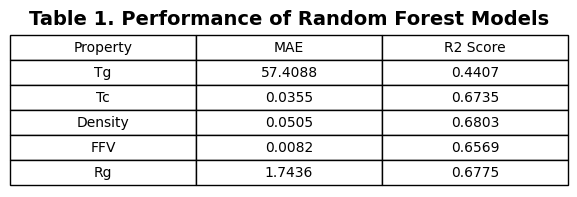

Saved as model_performance_table.png


In [18]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(6, 2))

# Hide axes
ax.axis('off')

# Create table
table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    loc='center',
    cellLoc='center'
)

# Adjust table style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Add title
plt.title("Table 1. Performance of Random Forest Models", fontsize=12, pad=10)
plt.title(
    "Table 1. Performance of Random Forest Models",
    fontsize=14,
    weight='bold'
)
# Save as PNG
plt.savefig("model_performance_table.png", dpi=300, bbox_inches='tight')

# Show table
plt.show()

print("Saved as model_performance_table.png")